In [1]:
import numpy as np

# Parametros del la simulación
n_3     = 0.1
divisor = 15
r       = np.linspace(0,1.5,16)
        
#Diametro de las particulas
sigma_3 = 1.0
sigma_2 = 10.0  * sigma_3
        
# Dimensiones del sistema
delta_x = sigma_3/divisor

# Elementos del mallado
x       = np.arange( sigma_2/2 - 2*sigma_3 , sigma_2 + 2*sigma_3 , delta_x)
y       = np.arange(      -3*sigma_3       ,     3*sigma_3       , delta_x)
z       = np.arange(      -3*sigma_3       ,     3*sigma_3       , delta_x)

# Arrays del mallado
xx, yy, zz = np.meshgrid(x, y,z,sparse=True)

# Ubicación de las esferas 2
X_2      = np.array([0,0,0])

# Diametros posibles de la esfera 1 
sigma_1  = np.linspace(2,10,5)* sigma_3

In [112]:
import time
# Verificar velocidad de ejecución
inicio = time.time()

#Inicializar donde se guardara el número de traslapes
num_tras = np.zeros((len(sigma_1),len(r)))

#Calcular iterativamente todos los valores de los traslapes
for j in range(len(sigma_1)):
    for i in range(len(r)):   
        # Ubicación de las esferas 1
        X_1      = np.array([(sigma_1[j]+sigma_2)/2 + r[i]*sigma_3 ,0,0])
         
        #Arrays con la distancia entre las esferas y cada punto del mallado
        d1          = np.sqrt( (X_1[0]-xx)**2 + (X_1[1]-yy)**2 + (X_1[2]-zz)**2 )
        
        # Filtros que identifican si hay traslape entre las esferas grandes y las pequeñas del mallado
        # Son un array de bollenaos
        mask_1      = d1 <= (sigma_1[j]+sigma_3)/2       
        # Eliminar un gran array para ahorrar memoria 
        del(d1)
        
        #Repetir para la esfera 2
        d2          = np.sqrt( (X_2[0]-xx)**2 + (X_2[1]-yy)**2 + (X_2[2]-zz)**2 )
        d2          = d2[mask_1]
        mask_2      = d2 <= (sigma_2+sigma_3)/2
        # Eliminar un gran array para ahorrar memoria 
        del(d2,mask_1)
        
        # Número de elementos con traslape de ambas esferas
        num_tras[j,i] = len(mask_2[mask_2])
        del(mask_2)

# Medir cuanto dura el proceso con finalidades de optimización
fin = time.time()
print(fin-inicio) 

beta_u_ef =  -num_tras*n_3*(delta_x**3)
np.savetxt("beta_u_es_delta_x_"+str(int(divisor))+"_s_1.csv", beta_u_ef, delimiter=",")

0.026459455490112305


In [2]:
def beta_u_fun(n_3,sigma_3,sigma_1,sigma_2,r):
    R_red     = r + (sigma_1 + sigma_2) / (2*sigma_3) 
    phi_3     = n_3 * (sigma_3**3) * np.pi / 6 
    eta_1     = sigma_1/sigma_3
    eta_2     = sigma_2/sigma_3
    eta_bar   = ( eta_1 + eta_2 )/2
    resultado = (    -phi_3 * ((eta_bar + 1)**3  -  3/2 * (eta_bar + 1)**2 *  R_red  +  1/2 *  R_red **3 ) 
                 +  (3*phi_3) / ( 8* R_red )  *  (eta_1-eta_2)**2  * ( ( eta_bar + 1 ) - R_red )**2  )
    for i in range(len(r)): 
        if r[i] > 1: resultado[i] = 0
    return    resultado

In [7]:
beta_u_delta_x_5  = np.loadtxt("beta_u_es_delta_x_5.csv",  delimiter=",")
beta_u_delta_x_10 = np.loadtxt("beta_u_es_delta_x_10.csv", delimiter=",")
beta_u_delta_x_15 = np.loadtxt("beta_u_es_delta_x_15.csv", delimiter=",")
beta_u_delta_x_20 = np.loadtxt("beta_u_es_delta_x_20.csv", delimiter=",")
beta_u_delta_x_25 = np.loadtxt("beta_u_es_delta_x_25.csv", delimiter=",")
beta_u_delta_x_30 = np.loadtxt("beta_u_es_delta_x_30.csv", delimiter=",")
beta_u_delta_x_35 = np.loadtxt("beta_u_es_delta_x_35.csv", delimiter=",")
beta_u_delta_x_40 = np.loadtxt("beta_u_es_delta_x_40.csv", delimiter=",")

std_x_5   = 0; std_x_10  = 0; std_x_15  = 0; std_x_20  = 0
std_x_25  = 0; std_x_30  = 0; std_x_35  = 0; std_x_40  = 0
               
for j in range(len(sigma_1)):
    std_x_5   += np.sum( (beta_u_delta_x_5[j]  - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_10  += np.sum( (beta_u_delta_x_10[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_15  += np.sum( (beta_u_delta_x_15[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_20  += np.sum( (beta_u_delta_x_20[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_25  += np.sum( (beta_u_delta_x_25[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_30  += np.sum( (beta_u_delta_x_30[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_35  += np.sum( (beta_u_delta_x_35[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
    std_x_40  += np.sum( (beta_u_delta_x_40[j] - beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r) )**2 )
               
std_x_5        = np.sqrt( std_x_5  / (len(sigma_1)*len(r)) )
std_x_10       = np.sqrt( std_x_10 / (len(sigma_1)*len(r)) )
std_x_15       = np.sqrt( std_x_15 / (len(sigma_1)*len(r)) )
std_x_20       = np.sqrt( std_x_20 / (len(sigma_1)*len(r)) )
std_x_25       = np.sqrt( std_x_25 / (len(sigma_1)*len(r)) )
std_x_30       = np.sqrt( std_x_30 / (len(sigma_1)*len(r)) )
std_x_35       = np.sqrt( std_x_35 / (len(sigma_1)*len(r)) )
std_x_40       = np.sqrt( std_x_40 / (len(sigma_1)*len(r)) )    

print('La deviación estándar de sigma_5  =',std_x_5 )
print('La deviación estándar de sigma_10 =',std_x_10)
print('La deviación estándar de sigma_15 =',std_x_15)
print('La deviación estándar de sigma_20 =',std_x_20)
print('La deviación estándar de sigma_25 =',std_x_25)
print('La deviación estándar de sigma_30 =',std_x_30)
print('La deviación estándar de sigma_35 =',std_x_35)
print('La deviación estándar de sigma_40 =',std_x_40)

La deviación estándar de sigma_5  = 0.011602856809623611
La deviación estándar de sigma_10 = 0.0044768243308695
La deviación estándar de sigma_15 = 0.001441540080491369
La deviación estándar de sigma_20 = 0.0009480121277862791
La deviación estándar de sigma_25 = 0.0005984832440411134
La deviación estándar de sigma_30 = 0.0004011939373466742
La deviación estándar de sigma_35 = 0.00021662402416704006
La deviación estándar de sigma_40 = 0.00029480134322275477


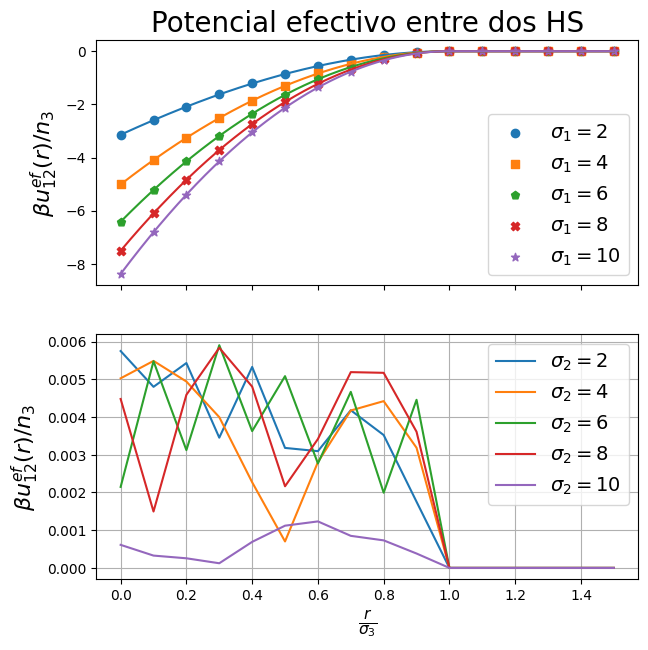

In [6]:
import matplotlib.pyplot as plt

beta_u_ef = np.loadtxt("beta_u_es_delta_x_40_s_1.csv",
				                 delimiter=",")

    
fig, axs = plt.subplots(2,1, sharex=True,figsize=[7, 7])

r1  = np.linspace(0,1.5,1000)

markers = ['o','s','p',"X","*"]
for j in range(len(sigma_1)):
    axs[0].scatter( r, beta_u_ef[j]/n_3, label=r'$\sigma_1=$'+str(int(sigma_1[j])), marker= markers[j])
    axs[0].plot(r1, beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r1)/n_3 )
    
    axs[1].plot(r, beta_u_ef[j]/n_3- beta_u_fun( n_3,sigma_3,sigma_1[j],sigma_2,r)/n_3, label=r'$\sigma_2=$'+str(int(sigma_1[j])) )

axs[0].set_title('Potencial efectivo entre dos HS', fontsize=20)
axs[0].set_ylabel(r'$\beta u_{12}^{ef}(r)/n_3$', fontsize=16)
axs[1].set_ylabel(r'$\beta u_{12}^{ef}(r)/n_3$', fontsize=16)
axs[1].set_xlabel(r'$\frac{r}{\sigma_3}$', fontsize=16)
axs[0].legend(fontsize=14)
axs[1].legend(fontsize=14)
plt.grid(True)
plt.savefig("Grafico_esferas_s_1.png", dpi=500)
plt.show()